STEP 1 — LOAD & UNDERSTAND DATA

In [1]:
# ==============================
# IMPORT LIBRARIES
# ==============================

import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

# ==============================
# LOAD DATASET
# ==============================

df = pd.read_csv("Cellphone.csv")

# ==============================
# BASIC UNDERSTANDING
# ==============================

print("Shape of dataset:")
print(df.shape)

print("\nFirst 5 Rows:")
display(df.head())

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
display(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Shape of dataset:
(161, 14)

First 5 Rows:


,Product_id,Price,Sale,weight,resolution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
0,203,2357,10,135.0,5.2,424,8,1.35,16.0,3.000,13.00,8.0,2610,7.4
1,880,1749,10,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9
2,40,1916,10,110.0,4.7,312,4,1.20,8.0,1.500,13.00,5.0,2000,7.6
3,99,1315,11,118.5,4.0,233,2,1.30,4.0,0.512,3.15,0.0,1400,11.0
4,880,1749,11,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product_id    161 non-null    int64  
 1   Price         161 non-null    int64  
 2   Sale          161 non-null    int64  
 3   weight        161 non-null    float64
 4   resolution    161 non-null    float64
 5   ppi           161 non-null    int64  
 6   cpu core      161 non-null    int64  
 7   cpu freq      161 non-null    float64
 8   internal mem  161 non-null    float64
 9   ram           161 non-null    float64
 10  RearCam       161 non-null    float64
 11  Front_Cam     161 non-null    float64
 12  battery       161 non-null    int64  
 13  thickness     161 non-null    float64
dtypes: float64(8), int64(6)
memory usage: 17.7 KB
None

Statistical Summary:


,Product_id,Price,Sale,weight,resolution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
count,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000
mean,675.559006,2215.596273,621.465839,170.426087,5.209938,335.055901,4.857143,1.502832,24.501714,2.204994,10.378261,4.503106,2842.111801,8.921739
std,410.851583,768.187171,1546.618517,92.888612,1.509953,134.826659,2.444016,0.599783,28.804773,1.609831,6.181585,4.342053,1366.990838,2.192564
min,10.000000,614.000000,10.000000,66.000000,1.400000,121.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,800.000000,5.100000
25%,237.000000,1734.000000,37.000000,134.100000,4.800000,233.000000,4.000000,1.200000,8.000000,1.000000,5.000000,0.000000,2040.000000,7.600000
50%,774.000000,2258.000000,106.000000,153.000000,5.150000,294.000000,4.000000,1.400000,16.000000,2.000000,12.000000,5.000000,2800.000000,8.400000
75%,1026.000000,2744.000000,382.000000,170.000000,5.500000,428.000000,8.000000,1.875000,32.000000,3.000000,16.000000,8.000000,3240.000000,9.800000
max,1339.000000,4361.000000,9807.000000,753.000000,12.200000,806.000000,8.000000,2.700000,128.000000,6.000000,23.000000,20.000000,9500.000000,18.500000



Missing Values:
Product_id      0
Price           0
Sale            0
weight          0
resolution      0
ppi             0
cpu core        0
cpu freq        0
internal mem    0
ram             0
RearCam         0
Front_Cam       0
battery         0
thickness       0
dtype: int64

Duplicate Rows:
0


Removing Non-Informative Features

Because:
Product IDs do not represent phone specifications
They have no logical relationship with price
Keeping them can introduce noise
Model may learn fake/random patterns

In [2]:
# Drop Product_id column

df.drop("Product_id", axis=1, inplace=True)

# Verify columns
print(df.columns)

Index(['Price', 'Sale', 'weight', 'resolution', 'ppi', 'cpu core', 'cpu freq',
       'internal mem', 'ram', 'RearCam', 'Front_Cam', 'battery', 'thickness'],
      dtype='str')


NEXT STEP — DISTRIBUTION ANALYSIS (EDA Phase 1)

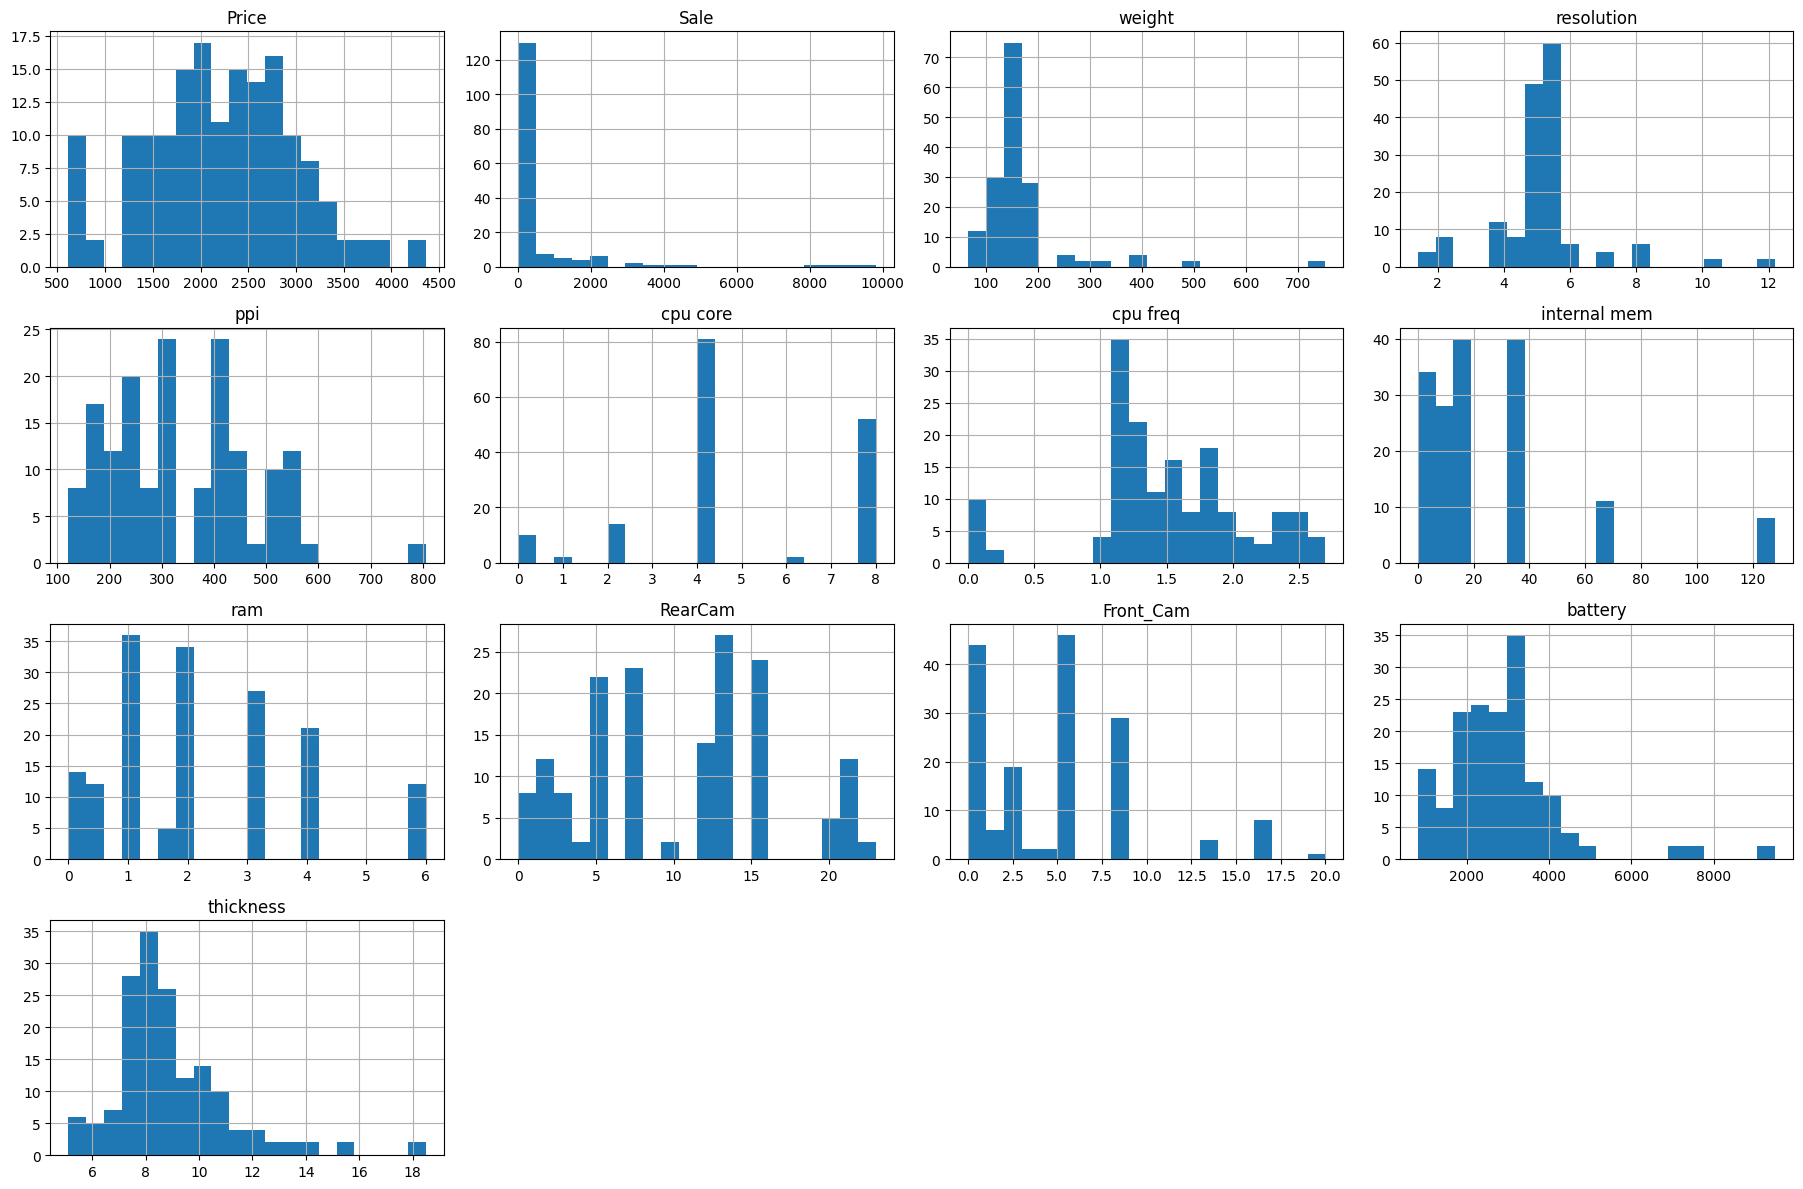

In [3]:
# ==============================
# HISTOGRAMS OF ALL FEATURES
# ==============================

df.hist(figsize=(18, 12), bins=20)

plt.tight_layout()
plt.show()

INTERPRETATION OF HISTOGRAMS
1. Features that look approximately normal - These are relatively well distributed: Price, resolution, cpu freq, battery (moderately), thickness
These usually work well with linear models.

2. Highly Skewed Features - These are clearly right-skewed: Sale, weight, internal mem, ram, Front_Cam
These may need transformation later.

3. Discrete Features - These are discrete numerical values: cpu core, ram, internal mem
This is completely fine.

4. Possible Outliers - Potential outliers visible in: Sale, weight, ppi, battery, thickness

NEXT STEP — MEASURE SKEWNESS MATHEMATICALLY

In [4]:
# ==============================
# CHECK SKEWNESS
# ==============================

skewness = df.skew()

print(skewness.sort_values(ascending=False))

Sale            4.269384
weight          3.981756
internal mem    2.389683
battery         2.092660
thickness       1.587680
resolution      1.176110
Front_Cam       1.169750
ram             0.792698
ppi             0.602503
RearCam         0.106929
Price           0.052347
cpu core       -0.009077
cpu freq       -0.512663
dtype: float64


Interpretation of Skewness Results

The skewness analysis shows that a few features are highly right-skewed, especially **Sale** and **weight**, indicating the presence of large values and outliers. Features like **internal mem**, **battery**, and **thickness** also show noticeable positive skewness, meaning their distributions are not perfectly balanced.

On the other hand, features such as **ram** and **ppi** have only moderate skewness, which is generally acceptable for machine learning models. Additionally, **Price**, **RearCam**, and **cpu core** are close to a normal distribution and do not require any treatment.

Since this is a relatively small dataset and some variables are naturally discrete, transforming every skewed feature is not necessary. Over-transformation can also reduce interpretability. Therefore, only the extremely skewed variables will be considered for transformation, while moderately skewed features will be kept as they are.

NEXT STEP — APPLY LOG TRANSFORMATION

In [5]:
# ==============================
# APPLY LOG TRANSFORMATION
# ==============================

skewed_cols = ['Sale', 'weight', 'internal mem', 'battery']

for col in skewed_cols:
    df[col] = np.log1p(df[col])

# Check skewness again
print(df[skewed_cols].skew())

Sale            0.614823
weight          1.322798
internal mem   -0.621898
battery        -0.361261
dtype: float64


Interpretation After Transformation

The transformation process significantly improved the distribution of the highly skewed features. Features like **Sale**, **internal mem**, and **battery** now have much more balanced distributions, making them better suited for regression modeling. Although **weight** still shows moderate skewness, its skewness value has reduced considerably compared to before.

At this stage, further transformation is not recommended because excessive transformations on a small dataset can distort feature relationships and reduce interpretability. Additionally, models such as Linear Regression, Ridge, and Lasso can still handle moderate skewness effectively, especially after feature scaling.

Overall, the dataset is now more model-friendly, with reduced skewness, stabilized distributions, and improved suitability for regression analysis.

NEXT STEP — CORRELATION ANALYSIS

In [6]:
# ==============================
# CORRELATION MATRIX
# ==============================

corr_matrix = df.corr()

# Correlation with target variable
price_corr = corr_matrix["Price"].sort_values(ascending=False)

print(price_corr)

Price           1.000000
internal mem    0.901374
ram             0.896915
ppi             0.817614
RearCam         0.739538
cpu freq        0.727383
battery         0.709592
cpu core        0.686811
Front_Cam       0.675286
resolution      0.404010
weight          0.309050
Sale            0.170567
thickness      -0.716773
Name: Price, dtype: float64


Interpretation of Correlation Results

The correlation analysis shows that the dataset has strong relationships between several features and the target variable (**Price**), making it highly suitable for regression modeling. Features such as **internal mem**, **ram**, **ppi**, **RearCam**, **cpu freq**, and **battery** show strong positive correlations with price, indicating that higher specifications generally lead to higher smartphone prices.

An important observation is that **thickness** has a strong negative correlation with price. This suggests that thinner phones are generally more expensive, while thicker phones tend to be lower priced. This relationship aligns well with real-world smartphone market trends, where premium devices are usually slimmer and more compact.

Some features like **Sale**, **weight**, and **resolution** show weaker correlations with price. However, these features will not be removed at this stage because regularization models such as Ridge and Lasso can automatically manage less important variables. Additionally, retaining features is beneficial for small datasets until multicollinearity analysis is completed.

NEXT STEP — HEATMAP

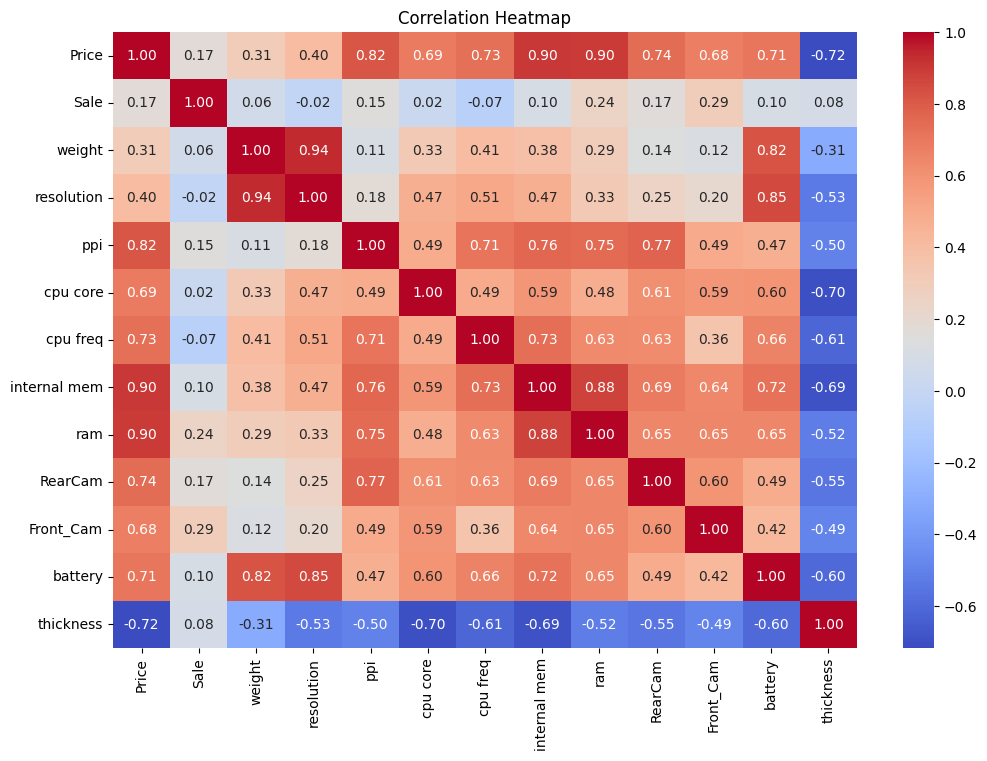

In [7]:
# ==============================
# CORRELATION HEATMAP
# ==============================

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Heatmap")
plt.show()

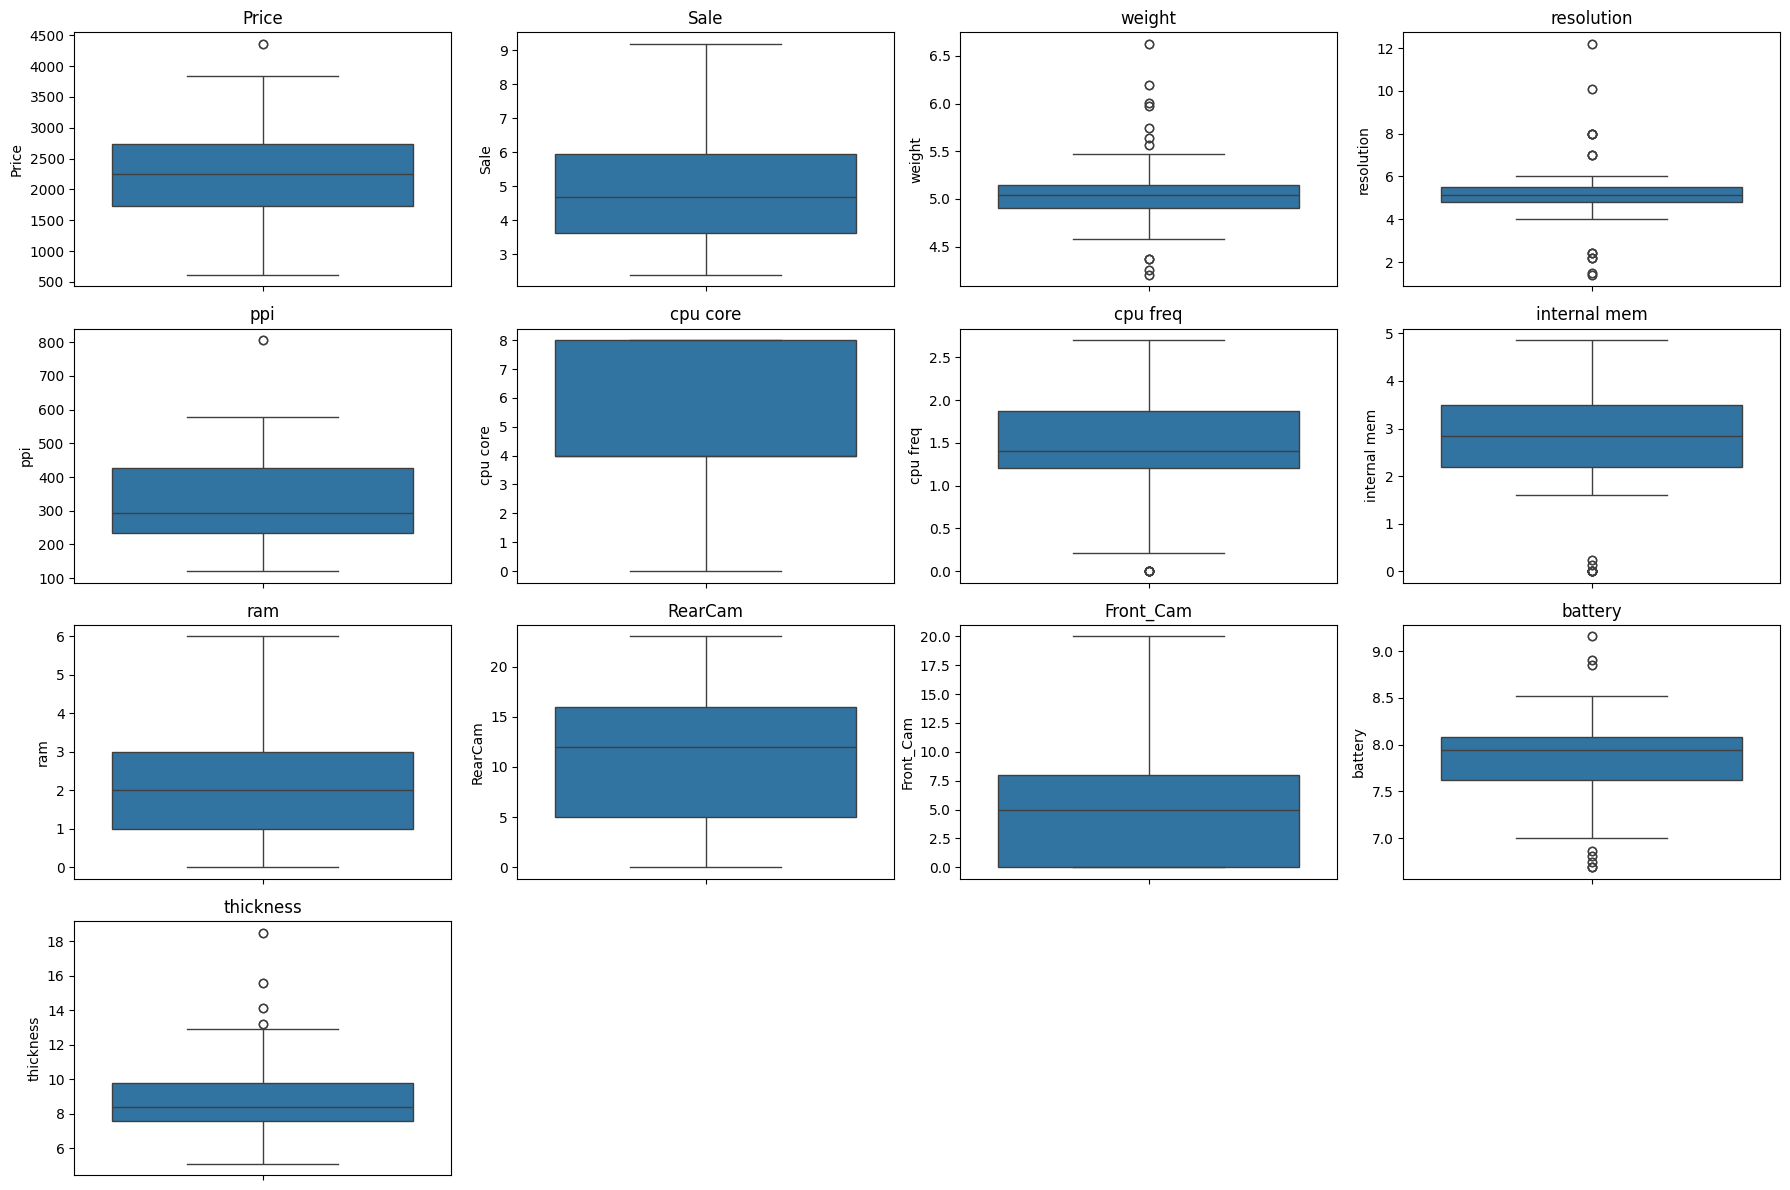

In [8]:
# ==============================
# BOXPLOTS
# ==============================

plt.figure(figsize=(18,12))

for i, col in enumerate(df.columns):
    plt.subplot(4,4,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [9]:
# ==============================
# SPLIT FEATURES & TARGET
# ==============================

X = df.drop("Price", axis=1)

y = df["Price"]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (161, 12)
Shape of y: (161,)


In [10]:
# ==============================
# TRAIN TEST SPLIT
# ==============================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (128, 12)
X_test shape: (33, 12)
y_train shape: (128,)
y_test shape: (33,)


In [11]:
# ==============================
# FEATURE SCALING
# ==============================

from sklearn.preprocessing import StandardScaler

# Create scaler object
scaler = StandardScaler()

# Fit on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (128, 12)
X_test_scaled shape: (33, 12)


In [12]:
# ==============================
# LINEAR REGRESSION MODEL
# ==============================

from sklearn.linear_model import LinearRegression

# Create model
lr_model = LinearRegression()

# Train model
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_lr = lr_model.predict(X_train_scaled)
y_test_pred_lr = lr_model.predict(X_test_scaled)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [13]:
# ==============================
# IMPORT METRICS
# ==============================

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import numpy as np

# ==============================
# R2 SCORE
# ==============================

train_r2 = r2_score(y_train, y_train_pred_lr)
test_r2 = r2_score(y_test, y_test_pred_lr)

# ==============================
# ADJUSTED R2
# ==============================

n_train = X_train.shape[0]
p_train = X_train.shape[1]

n_test = X_test.shape[0]
p_test = X_test.shape[1]

adj_train_r2 = 1 - (1 - train_r2) * (n_train - 1) / (n_train - p_train - 1)

adj_test_r2 = 1 - (1 - test_r2) * (n_test - 1) / (n_test - p_test - 1)

# ==============================
# ERROR METRICS
# ==============================

train_mae = mean_absolute_error(y_train, y_train_pred_lr)
test_mae = mean_absolute_error(y_test, y_test_pred_lr)

train_mse = mean_squared_error(y_train, y_train_pred_lr)
test_mse = mean_squared_error(y_test, y_test_pred_lr)

train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

train_mape = mean_absolute_percentage_error(y_train, y_train_pred_lr)
test_mape = mean_absolute_percentage_error(y_test, y_test_pred_lr)


# ==============================
# R2 SCORE
# ==============================

train_r2 = r2_score(y_train, y_train_pred_lr)
test_r2 = r2_score(y_test, y_test_pred_lr)


# ==============================
# CREATE PERFORMANCE TABLE
# ==============================

lr_results = pd.DataFrame({
    "Metric": ["R2 Score",
               "Adjusted R2",
               "MAE",
               "MSE",
               "RMSE",
               "MAPE"],

    "Training": [train_r2,
                 adj_train_r2,
                 train_mae,
                 train_mse,
                 train_rmse,
                 train_mape],

    "Testing": [test_r2,
                adj_test_r2,
                test_mae,
                test_mse,
                test_rmse,
                test_mape]
})

# Round values
lr_results = lr_results.round(4)

display(lr_results)

,Metric,Training,Testing
0,R2 Score,0.9446,0.9382
1,Adjusted R2,0.9388,0.9011
2,MAE,138.0606,157.0708
3,MSE,32758.3440,35046.8277
4,RMSE,180.9927,187.2080
5,MAPE,0.0706,0.0708


In [14]:
# ==============================
# RIDGE REGRESSION
# ==============================

from sklearn.linear_model import Ridge

# Create Ridge model
ridge_model = Ridge(alpha=1.0)

# Train model
ridge_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_ridge = ridge_model.predict(X_train_scaled)
y_test_pred_ridge = ridge_model.predict(X_test_scaled)

print("Ridge Regression model trained successfully.")

Ridge Regression model trained successfully.


In [15]:
# ==============================
# RIDGE REGRESSION METRICS
# ==============================

# R2 Score
ridge_train_r2 = r2_score(y_train, y_train_pred_ridge)
ridge_test_r2 = r2_score(y_test, y_test_pred_ridge)

# Adjusted R2
ridge_adj_train_r2 = 1 - (1 - ridge_train_r2) * (n_train - 1) / (n_train - p_train - 1)

ridge_adj_test_r2 = 1 - (1 - ridge_test_r2) * (n_test - 1) / (n_test - p_test - 1)

# Error Metrics
ridge_train_mae = mean_absolute_error(y_train, y_train_pred_ridge)
ridge_test_mae = mean_absolute_error(y_test, y_test_pred_ridge)

ridge_train_mse = mean_squared_error(y_train, y_train_pred_ridge)
ridge_test_mse = mean_squared_error(y_test, y_test_pred_ridge)

ridge_train_rmse = np.sqrt(ridge_train_mse)
ridge_test_rmse = np.sqrt(ridge_test_mse)

ridge_train_mape = mean_absolute_percentage_error(y_train, y_train_pred_ridge)
ridge_test_mape = mean_absolute_percentage_error(y_test, y_test_pred_ridge)

# ==============================
# CREATE RIDGE RESULTS TABLE
# ==============================

ridge_results = pd.DataFrame({
    "Metric": ["R2 Score",
               "Adjusted R2",
               "MAE",
               "MSE",
               "RMSE",
               "MAPE"],

    "Training": [ridge_train_r2,
                 ridge_adj_train_r2,
                 ridge_train_mae,
                 ridge_train_mse,
                 ridge_train_rmse,
                 ridge_train_mape],

    "Testing": [ridge_test_r2,
                ridge_adj_test_r2,
                ridge_test_mae,
                ridge_test_mse,
                ridge_test_rmse,
                ridge_test_mape]
})

ridge_results = ridge_results.round(4)

display(ridge_results)

,Metric,Training,Testing
0,R2 Score,0.9445,0.9368
1,Adjusted R2,0.9387,0.8988
2,MAE,137.7853,157.7084
3,MSE,32812.0271,35842.4203
4,RMSE,181.1409,189.3209
5,MAPE,0.0702,0.0710


In [16]:
# ==============================
# LASSO REGRESSION
# ==============================

from sklearn.linear_model import Lasso

# Create model
lasso_model = Lasso(alpha=1.0)

# Train model
lasso_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_lasso = lasso_model.predict(X_train_scaled)
y_test_pred_lasso = lasso_model.predict(X_test_scaled)

print("Lasso Regression model trained successfully.")

Lasso Regression model trained successfully.


In [17]:
# ==============================
# LASSO REGRESSION METRICS
# ==============================

# R2 Score
lasso_train_r2 = r2_score(y_train, y_train_pred_lasso)
lasso_test_r2 = r2_score(y_test, y_test_pred_lasso)

# Adjusted R2
lasso_adj_train_r2 = 1 - (1 - lasso_train_r2) * (n_train - 1) / (n_train - p_train - 1)

lasso_adj_test_r2 = 1 - (1 - lasso_test_r2) * (n_test - 1) / (n_test - p_test - 1)

# Error Metrics
lasso_train_mae = mean_absolute_error(y_train, y_train_pred_lasso)
lasso_test_mae = mean_absolute_error(y_test, y_test_pred_lasso)

lasso_train_mse = mean_squared_error(y_train, y_train_pred_lasso)
lasso_test_mse = mean_squared_error(y_test, y_test_pred_lasso)

lasso_train_rmse = np.sqrt(lasso_train_mse)
lasso_test_rmse = np.sqrt(lasso_test_mse)

lasso_train_mape = mean_absolute_percentage_error(y_train, y_train_pred_lasso)
lasso_test_mape = mean_absolute_percentage_error(y_test, y_test_pred_lasso)

# ==============================
# CREATE RESULTS TABLE
# ==============================

lasso_results = pd.DataFrame({
    "Metric": ["R2 Score",
               "Adjusted R2",
               "MAE",
               "MSE",
               "RMSE",
               "MAPE"],

    "Training": [lasso_train_r2,
                 lasso_adj_train_r2,
                 lasso_train_mae,
                 lasso_train_mse,
                 lasso_train_rmse,
                 lasso_train_mape],

    "Testing": [lasso_test_r2,
                lasso_adj_test_r2,
                lasso_test_mae,
                lasso_test_mse,
                lasso_test_rmse,
                lasso_test_mape]
})

lasso_results = lasso_results.round(4)

display(lasso_results)

,Metric,Training,Testing
0,R2 Score,0.9445,0.9376
1,Adjusted R2,0.9387,0.9002
2,MAE,137.9838,157.1246
3,MSE,32796.1052,35360.0098
4,RMSE,181.0969,188.0426
5,MAPE,0.0702,0.0707


In [19]:
# ==============================
# ELASTICNET REGRESSION
# ==============================

from sklearn.linear_model import ElasticNet

# Create model
elastic_model = ElasticNet(alpha=1.0, l1_ratio=0.5)

# Train model
elastic_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_elastic = elastic_model.predict(X_train_scaled)
y_test_pred_elastic = elastic_model.predict(X_test_scaled)

print("ElasticNet Regression model trained successfully.")

ElasticNet Regression model trained successfully.


In [20]:
# ==============================
# ELASTICNET METRICS
# ==============================

# R2 Score
elastic_train_r2 = r2_score(y_train, y_train_pred_elastic)
elastic_test_r2 = r2_score(y_test, y_test_pred_elastic)

# Adjusted R2
elastic_adj_train_r2 = 1 - (1 - elastic_train_r2) * (n_train - 1) / (n_train - p_train - 1)

elastic_adj_test_r2 = 1 - (1 - elastic_test_r2) * (n_test - 1) / (n_test - p_test - 1)

# Error Metrics
elastic_train_mae = mean_absolute_error(y_train, y_train_pred_elastic)
elastic_test_mae = mean_absolute_error(y_test, y_test_pred_elastic)

elastic_train_mse = mean_squared_error(y_train, y_train_pred_elastic)
elastic_test_mse = mean_squared_error(y_test, y_test_pred_elastic)

elastic_train_rmse = np.sqrt(elastic_train_mse)
elastic_test_rmse = np.sqrt(elastic_test_mse)

elastic_train_mape = mean_absolute_percentage_error(y_train, y_train_pred_elastic)
elastic_test_mape = mean_absolute_percentage_error(y_test, y_test_pred_elastic)

# ==============================
# CREATE RESULTS TABLE
# ==============================

elastic_results = pd.DataFrame({
    "Metric": ["R2 Score",
               "Adjusted R2",
               "MAE",
               "MSE",
               "RMSE",
               "MAPE"],

    "Training": [elastic_train_r2,
                 elastic_adj_train_r2,
                 elastic_train_mae,
                 elastic_train_mse,
                 elastic_train_rmse,
                 elastic_train_mape],

    "Testing": [elastic_test_r2,
                elastic_adj_test_r2,
                elastic_test_mae,
                elastic_test_mse,
                elastic_test_rmse,
                elastic_test_mape]
})

elastic_results = elastic_results.round(4)

display(elastic_results)

,Metric,Training,Testing
0,R2 Score,0.9213,0.8944
1,Adjusted R2,0.9131,0.8310
2,MAE,155.1347,171.4403
3,MSE,46529.0932,59873.5248
4,RMSE,215.7060,244.6907
5,MAPE,0.0743,0.0779


In [21]:
# ==============================
# PROFESSIONAL FINAL SUMMARY TABLE
# ==============================

summary_results = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "ElasticNet Regression"
    ],

    "Train R2": [
        train_r2,
        ridge_train_r2,
        lasso_train_r2,
        elastic_train_r2
    ],

    "Test R2": [
        test_r2,
        ridge_test_r2,
        lasso_test_r2,
        elastic_test_r2
    ],

    "Train RMSE": [
        train_rmse,
        ridge_train_rmse,
        lasso_train_rmse,
        elastic_train_rmse
    ],

    "Test RMSE": [
        test_rmse,
        ridge_test_rmse,
        lasso_test_rmse,
        elastic_test_rmse
    ],

    "Train MAPE": [
        train_mape,
        ridge_train_mape,
        lasso_train_mape,
        elastic_train_mape
    ],

    "Test MAPE": [
        test_mape,
        ridge_test_mape,
        lasso_test_mape,
        elastic_test_mape
    ]
})

summary_results = summary_results.round(4)

display(summary_results)

,Model,Train R2,Test R2,Train RMSE,Test RMSE,Train MAPE,Test MAPE
0,Linear Regression,0.9446,0.9382,180.9927,187.2080,0.0706,0.0708
1,Ridge Regression,0.9445,0.9368,181.1409,189.3209,0.0702,0.0710
2,Lasso Regression,0.9445,0.9376,181.0969,188.0426,0.0702,0.0707
3,ElasticNet Regression,0.9213,0.8944,215.7060,244.6907,0.0743,0.0779


In [27]:
# ==============================
# FEATURE IMPORTANCE DATAFRAME
# ==============================

feature_importance = pd.DataFrame({

    "Feature": X.columns,
    "Coefficient": lr_model.coef_

})

# Absolute importance
feature_importance["Absolute_Coefficient"] = abs(feature_importance["Coefficient"])

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

display(feature_importance)

,Feature,Coefficient,Absolute_Coefficient
7,ram,286.811991,286.811991
10,battery,183.073686,183.073686
11,thickness,-160.296430,160.296430
3,ppi,158.766444,158.766444
2,resolution,-144.466736,144.466736
4,cpu core,103.393946,103.393946
6,internal mem,63.593171,63.593171
5,cpu freq,48.744357,48.744357
0,Sale,28.229503,28.229503
8,RearCam,-24.539585,24.539585


In [28]:
feature_importance.to_csv("feature_importance.csv", index=False)

print("Feature importance file saved successfully.")

Feature importance file saved successfully.


In [25]:
# ==============================
# SAVE MODEL & SCALER
# ==============================

import joblib

# Save Linear Regression Model
joblib.dump(lr_model, "mobile_price_model.pkl")

# Save Scaler
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully.")

Model and scaler saved successfully.
